# Анализ датасета: Прогнозирование поступления в университет

---

## 1. Описание набора данных

**Graduate Admission 2** — датасет, предназначенный для прогнозирования шансов поступления студентов в магистратуру в университеты США. Данные вдохновлены UCLA Graduate Dataset и созданы Mohan S Acharya.

### Целевая задача
Регрессия: предсказать **вероятность поступления** (`Chance of Admit`) на основе академических и профессиональных характеристик абитуриента.

### Описание признаков

| Признак | Тип | Описание |
|---|---|---|
| `Serial No.` | int | Порядковый номер записи |
| `GRE Score` | int | Балл экзамена GRE (260–340) |
| `TOEFL Score` | int | Балл экзамена TOEFL (0–120) |
| `University Rating` | int | Рейтинг университета (1–5) |
| `SOP` | float | Оценка мотивационного письма (1.0–5.0) |
| `LOR` | float | Оценка рекомендательного письма (1.0–5.0) |
| `CGPA` | float | Средний балл диплома (0–10) |
| `Research` | int | Наличие опыта исследовательской работы (0 или 1) |
| `Chance of Admit` | float | **Целевая переменная** — вероятность поступления (0.0–1.0) |

In [2]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from matplotlib.gridspec import GridSpec

# Настройка стиля графиков
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

# Загрузка данных
df = pd.read_csv('Admission_Predict.csv')

# Удаляем служебный столбец
df = df.drop(columns=['Serial No.'])

# Переименуем для удобства
df.columns = ['GRE Score', 'TOEFL Score', 'University Rating',
              'SOP', 'LOR', 'CGPA', 'Research', 'Chance of Admit']

print('Датасет успешно загружен!')
df.head()

Датасет успешно загружен!


,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


---

## 2. Основные характеристики датасета

In [3]:
print('=' * 55)
print('  ОБЩАЯ ИНФОРМАЦИЯ О ДАТАСЕТЕ')
print('=' * 55)
print(f'  Количество наблюдений : {df.shape[0]}')
print(f'  Количество признаков  : {df.shape[1]}')
print(f'  Пропущенные значения  : {df.isnull().sum().sum()}')
print(f'  Дубликаты строк       : {df.duplicated().sum()}')
print('=' * 55)

print('\nТипы данных:')
print(df.dtypes)

print('\nРаспределение по категориальному признаку "Research":')
vc = df['Research'].value_counts()
print(f'  Без опыта (0): {vc[0]} чел. ({vc[0]/len(df)*100:.1f}%)')
print(f'  С опытом  (1): {vc[1]} чел. ({vc[1]/len(df)*100:.1f}%)')

  ОБЩАЯ ИНФОРМАЦИЯ О ДАТАСЕТЕ
  Количество наблюдений : 400
  Количество признаков  : 8
  Пропущенные значения  : 0
  Дубликаты строк       : 0

Типы данных:
GRE Score              int64
TOEFL Score            int64
University Rating      int64
SOP                  float64
LOR                  float64
CGPA                 float64
Research               int64
Chance of Admit      float64
dtype: object

Распределение по категориальному признаку "Research":
  Без опыта (0): 181 чел. (45.2%)
  С опытом  (1): 219 чел. (54.8%)


In [5]:
print('Описательная статистика:')
df.describe().round(3)

Описательная статистика:


,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
count,400.000,400.00,400.000,400.000,400.000,400.000,400.000,400.000
mean,316.808,107.41,3.088,3.400,3.452,8.599,0.548,0.724
std,11.474,6.07,1.144,1.007,0.898,0.596,0.498,0.143
min,290.000,92.00,1.000,1.000,1.000,6.800,0.000,0.340
25%,308.000,103.00,2.000,2.500,3.000,8.170,0.000,0.640
50%,317.000,107.00,3.000,3.500,3.500,8.610,1.000,0.730
75%,325.000,112.00,4.000,4.000,4.000,9.062,1.000,0.830
max,340.000,120.00,5.000,5.000,5.000,9.920,1.000,0.970


---

## 3. Визуальное исследование датасета

### 3.1 Распределение целевой переменной

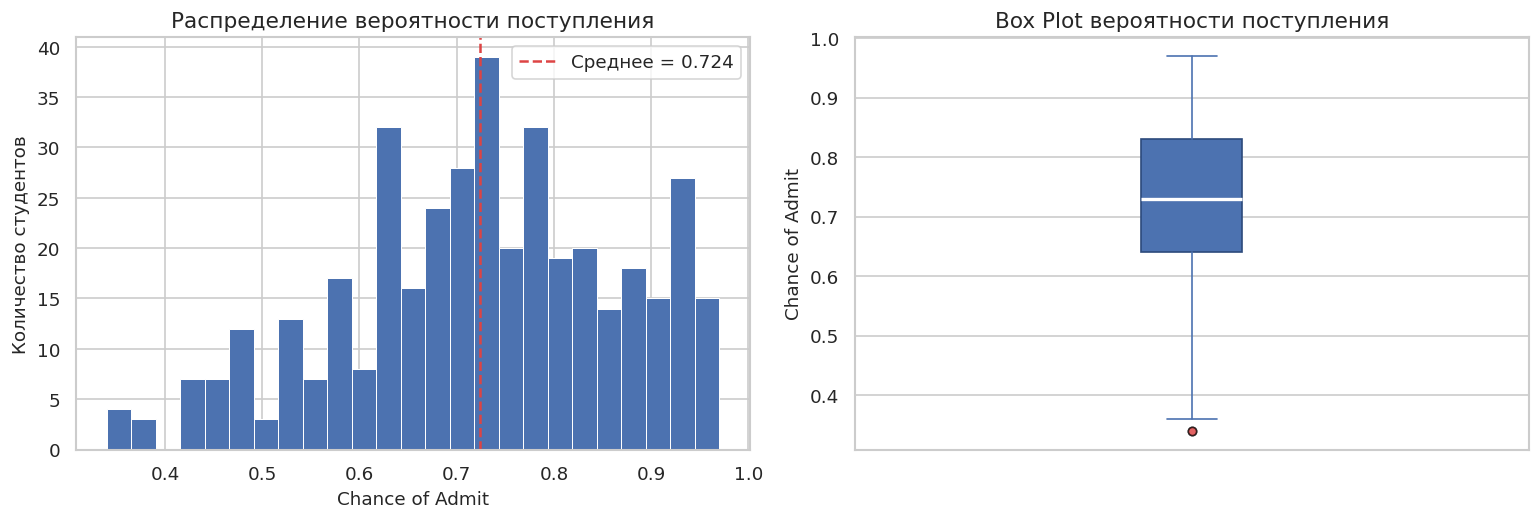

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Гистограмма
axes[0].hist(df['Chance of Admit'], bins=25, color='#4C72B0', edgecolor='white', linewidth=0.6)
axes[0].set_title('Распределение вероятности поступления')
axes[0].set_xlabel('Chance of Admit')
axes[0].set_ylabel('Количество студентов')
mean_val = df['Chance of Admit'].mean()
axes[0].axvline(mean_val, color='#DD4444', linestyle='--', linewidth=1.5, label=f'Среднее = {mean_val:.3f}')
axes[0].legend()

# Ящик с усами
bp = axes[1].boxplot(df['Chance of Admit'], vert=True, patch_artist=True,
                     boxprops=dict(facecolor='#4C72B0', color='#2c4a7c'),
                     medianprops=dict(color='white', linewidth=2),
                     whiskerprops=dict(color='#4C72B0'),
                     capprops=dict(color='#4C72B0'),
                     flierprops=dict(marker='o', markerfacecolor='#DD4444', markersize=5, alpha=0.6))
axes[1].set_title('Box Plot вероятности поступления')
axes[1].set_ylabel('Chance of Admit')
axes[1].set_xticks([])

plt.tight_layout()
plt.savefig('plot_target.png', bbox_inches='tight')
plt.show()

### 3.2 Распределение числовых признаков

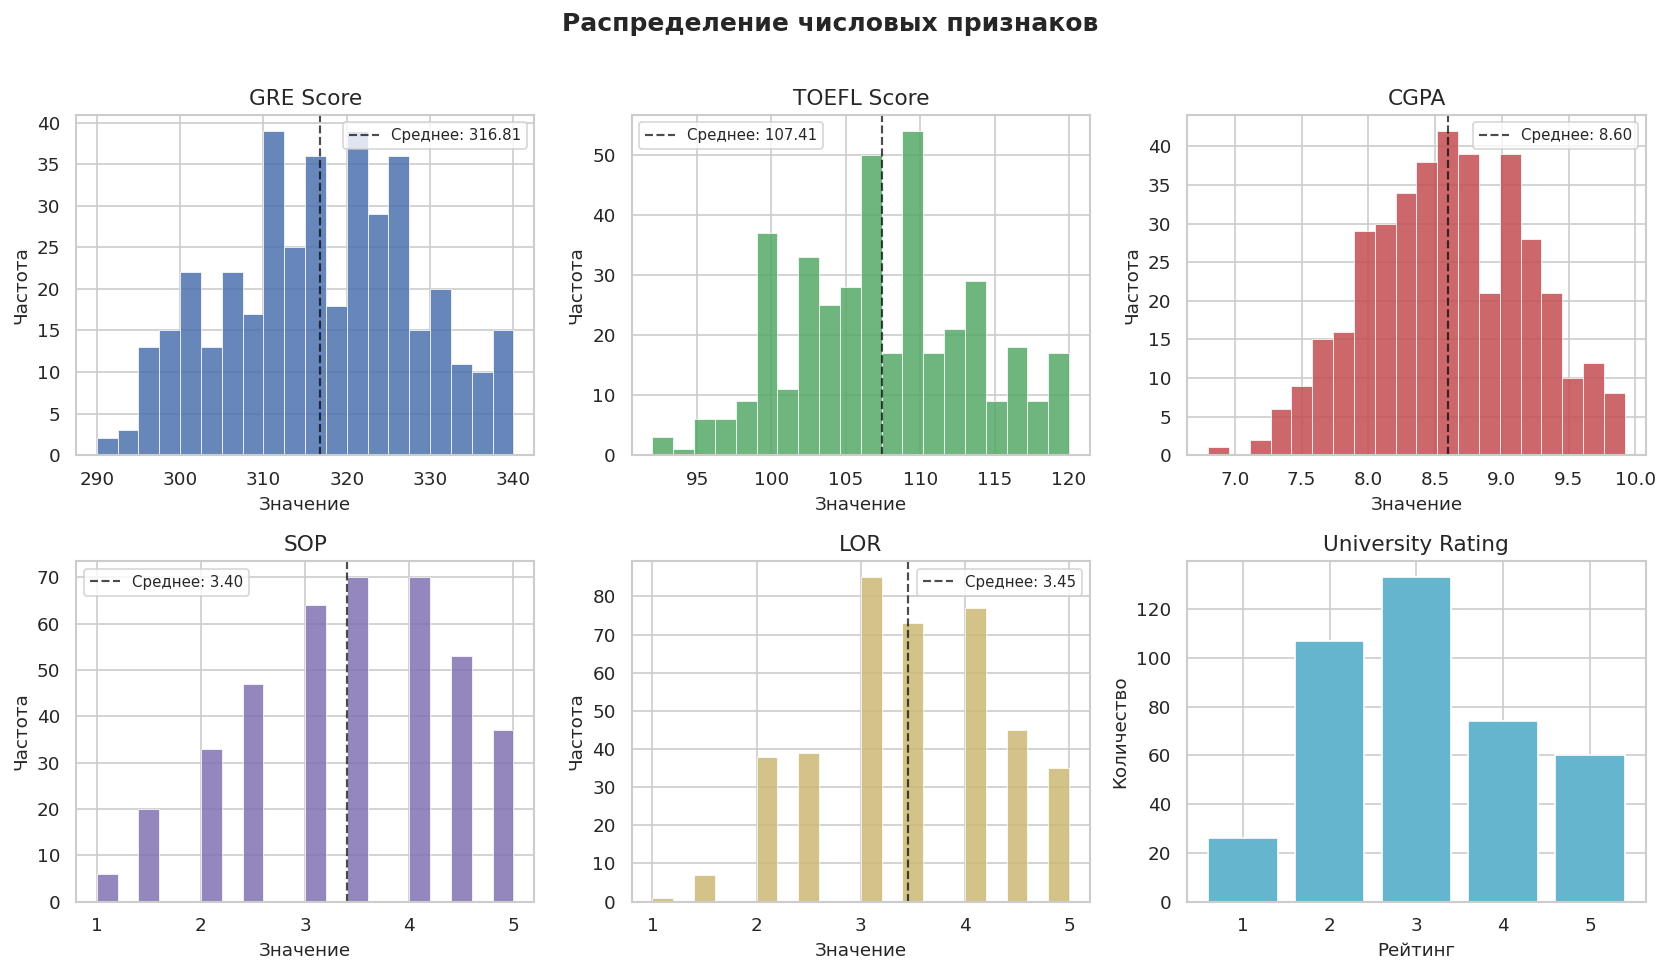

In [7]:
num_cols = ['GRE Score', 'TOEFL Score', 'CGPA', 'SOP', 'LOR']
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, (col, color) in enumerate(zip(num_cols, colors)):
    axes[i].hist(df[col], bins=20, color=color, edgecolor='white', linewidth=0.5, alpha=0.85)
    axes[i].set_title(col)
    axes[i].set_xlabel('Значение')
    axes[i].set_ylabel('Частота')
    mean = df[col].mean()
    axes[i].axvline(mean, color='black', linestyle='--', linewidth=1.3, alpha=0.7, label=f'Среднее: {mean:.2f}')
    axes[i].legend(fontsize=9)

# University Rating — столбчатая
rating_counts = df['University Rating'].value_counts().sort_index()
axes[5].bar(rating_counts.index, rating_counts.values, color='#64B5CD', edgecolor='white')
axes[5].set_title('University Rating')
axes[5].set_xlabel('Рейтинг')
axes[5].set_ylabel('Количество')
axes[5].set_xticks([1, 2, 3, 4, 5])

plt.suptitle('Распределение числовых признаков', fontsize=15, y=1.01, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_distributions.png', bbox_inches='tight')
plt.show()

### 3.3 Влияние опыта исследований на шансы поступления

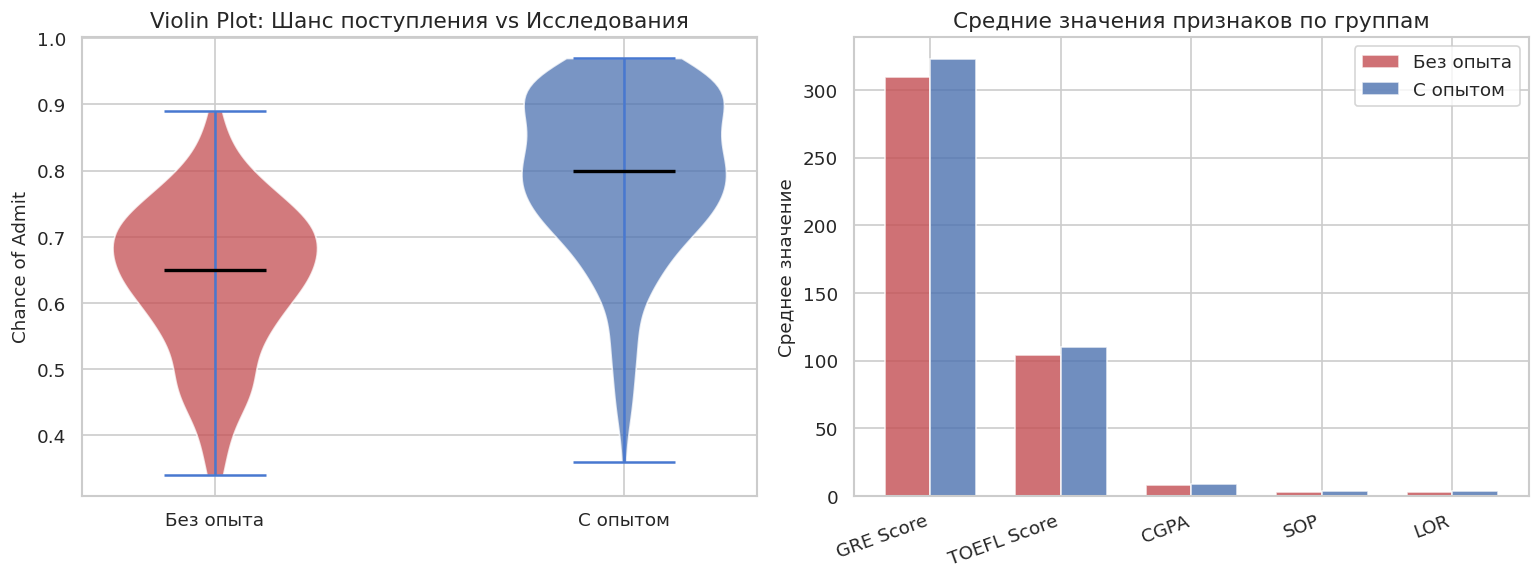

Средний шанс поступления:
  Без опыта исследований: 0.638
  С опытом исследований : 0.796


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Violin plot
research_groups = [df[df['Research'] == 0]['Chance of Admit'],
                   df[df['Research'] == 1]['Chance of Admit']]
vp = axes[0].violinplot(research_groups, positions=[0, 1], showmedians=True)
for i, pc in enumerate(vp['bodies']):
    pc.set_facecolor(['#C44E52', '#4C72B0'][i])
    pc.set_alpha(0.75)
vp['cmedians'].set_color('black')
vp['cmedians'].set_linewidth(2)
axes[0].set_title('Violin Plot: Шанс поступления vs Исследования')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Без опыта', 'С опытом'])
axes[0].set_ylabel('Chance of Admit')

# Средние значения признаков по группам
features = ['GRE Score', 'TOEFL Score', 'CGPA', 'SOP', 'LOR']
means_no = df[df['Research'] == 0][features].mean()
means_yes = df[df['Research'] == 1][features].mean()

x = np.arange(len(features))
width = 0.35
bars1 = axes[1].bar(x - width/2, means_no, width, label='Без опыта', color='#C44E52', alpha=0.8, edgecolor='white')
bars2 = axes[1].bar(x + width/2, means_yes, width, label='С опытом', color='#4C72B0', alpha=0.8, edgecolor='white')
axes[1].set_title('Средние значения признаков по группам')
axes[1].set_xticks(x)
axes[1].set_xticklabels(features, rotation=20, ha='right')
axes[1].set_ylabel('Среднее значение')
axes[1].legend()

plt.tight_layout()
plt.savefig('plot_research.png', bbox_inches='tight')
plt.show()

print('Средний шанс поступления:')
print(f'  Без опыта исследований: {df[df["Research"]==0]["Chance of Admit"].mean():.3f}')
print(f'  С опытом исследований : {df[df["Research"]==1]["Chance of Admit"].mean():.3f}')

### 3.4 Диаграммы рассеяния: ключевые признаки vs целевая переменная

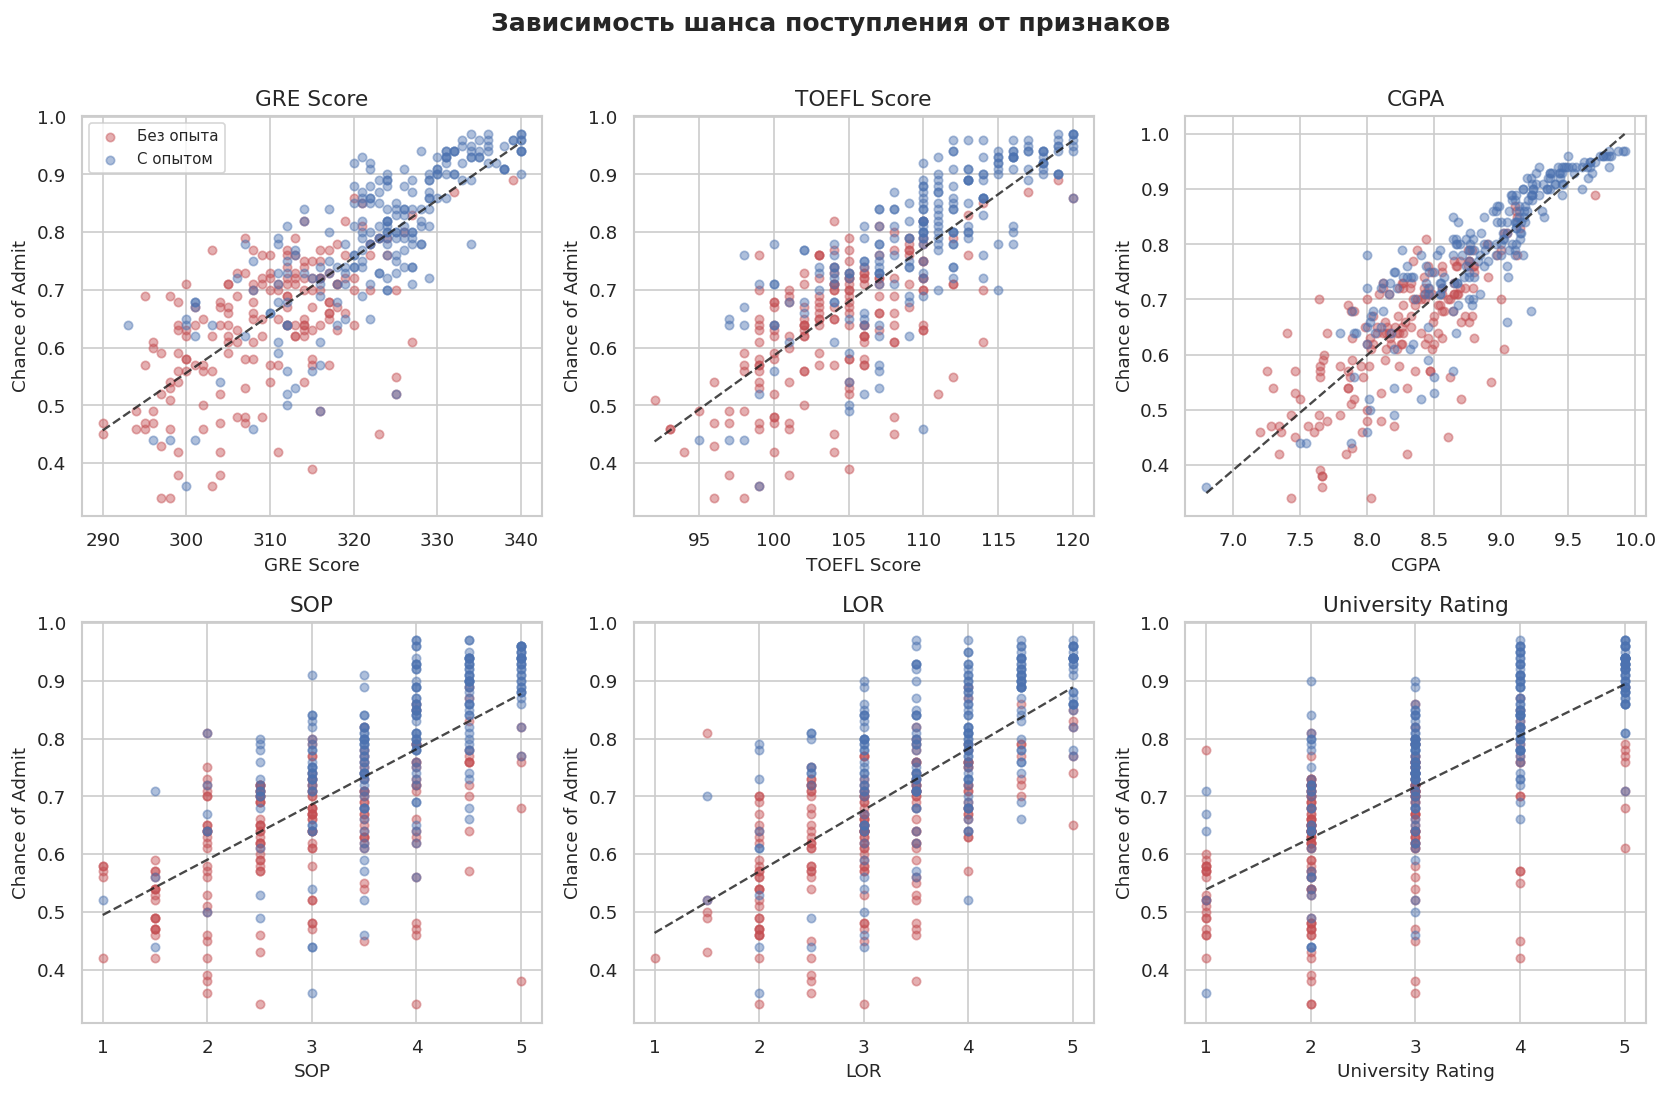

In [9]:
key_features = ['GRE Score', 'TOEFL Score', 'CGPA', 'SOP', 'LOR', 'University Rating']
palette = {0: '#C44E52', 1: '#4C72B0'}

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    for research_val, color in palette.items():
        mask = df['Research'] == research_val
        axes[i].scatter(df[mask][feat], df[mask]['Chance of Admit'],
                        color=color, alpha=0.45, s=25,
                        label='С опытом' if research_val == 1 else 'Без опыта')
    # Линия тренда
    z = np.polyfit(df[feat], df['Chance of Admit'], 1)
    p = np.poly1d(z)
    xline = np.linspace(df[feat].min(), df[feat].max(), 100)
    axes[i].plot(xline, p(xline), 'k--', linewidth=1.4, alpha=0.8)
    axes[i].set_title(feat)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Chance of Admit')
    if i == 0:
        axes[i].legend(fontsize=9)

plt.suptitle('Зависимость шанса поступления от признаков', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_scatter.png', bbox_inches='tight')
plt.show()

---

## 4. Корреляционный анализ

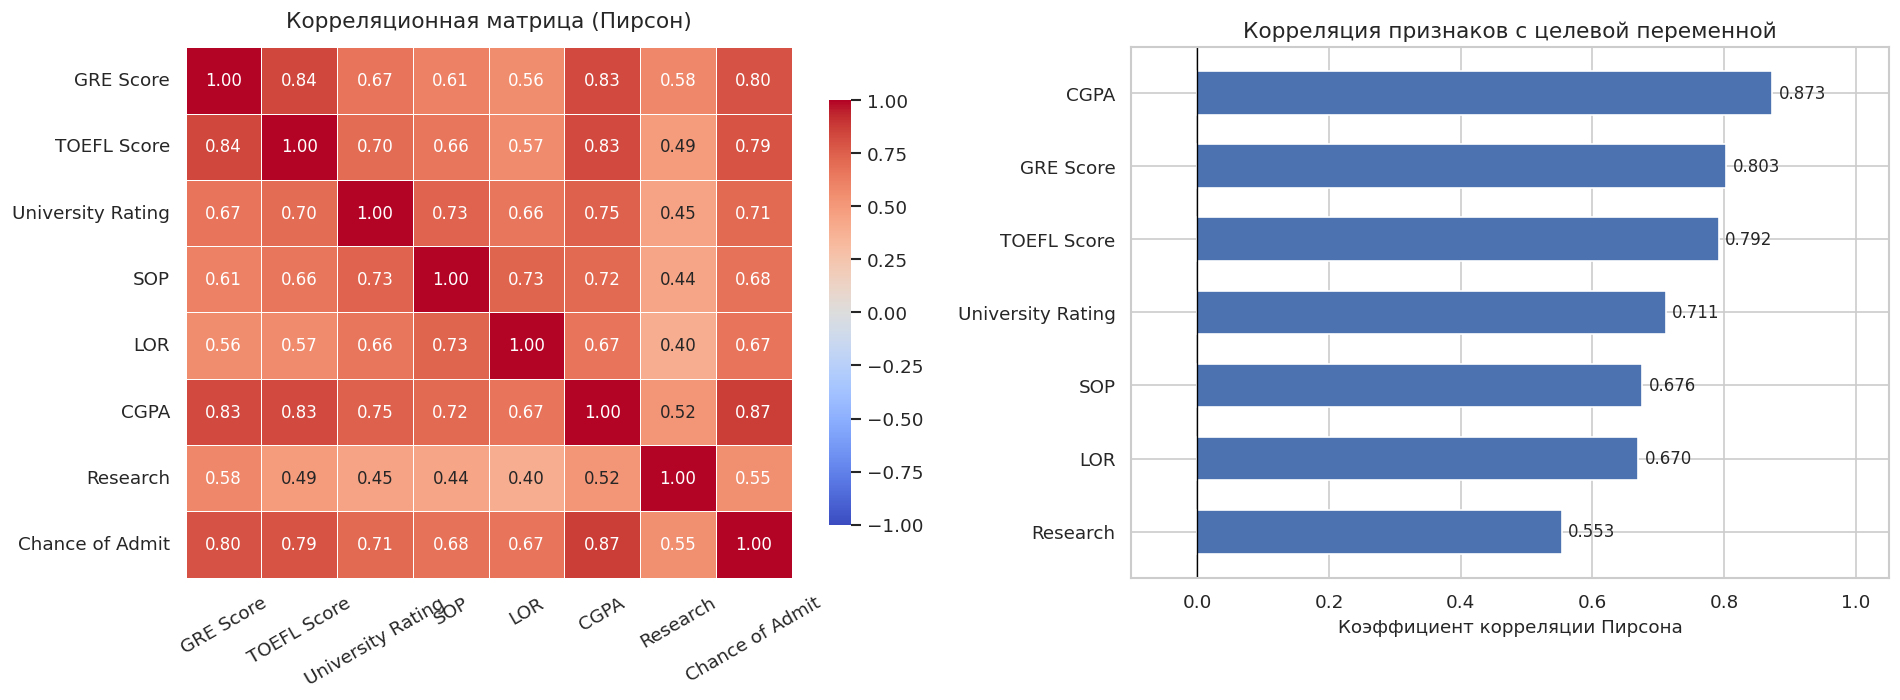

In [ ]:
corr = df.corr()

print('Матрица корреляции (Пирсон):')
corr.round(3)

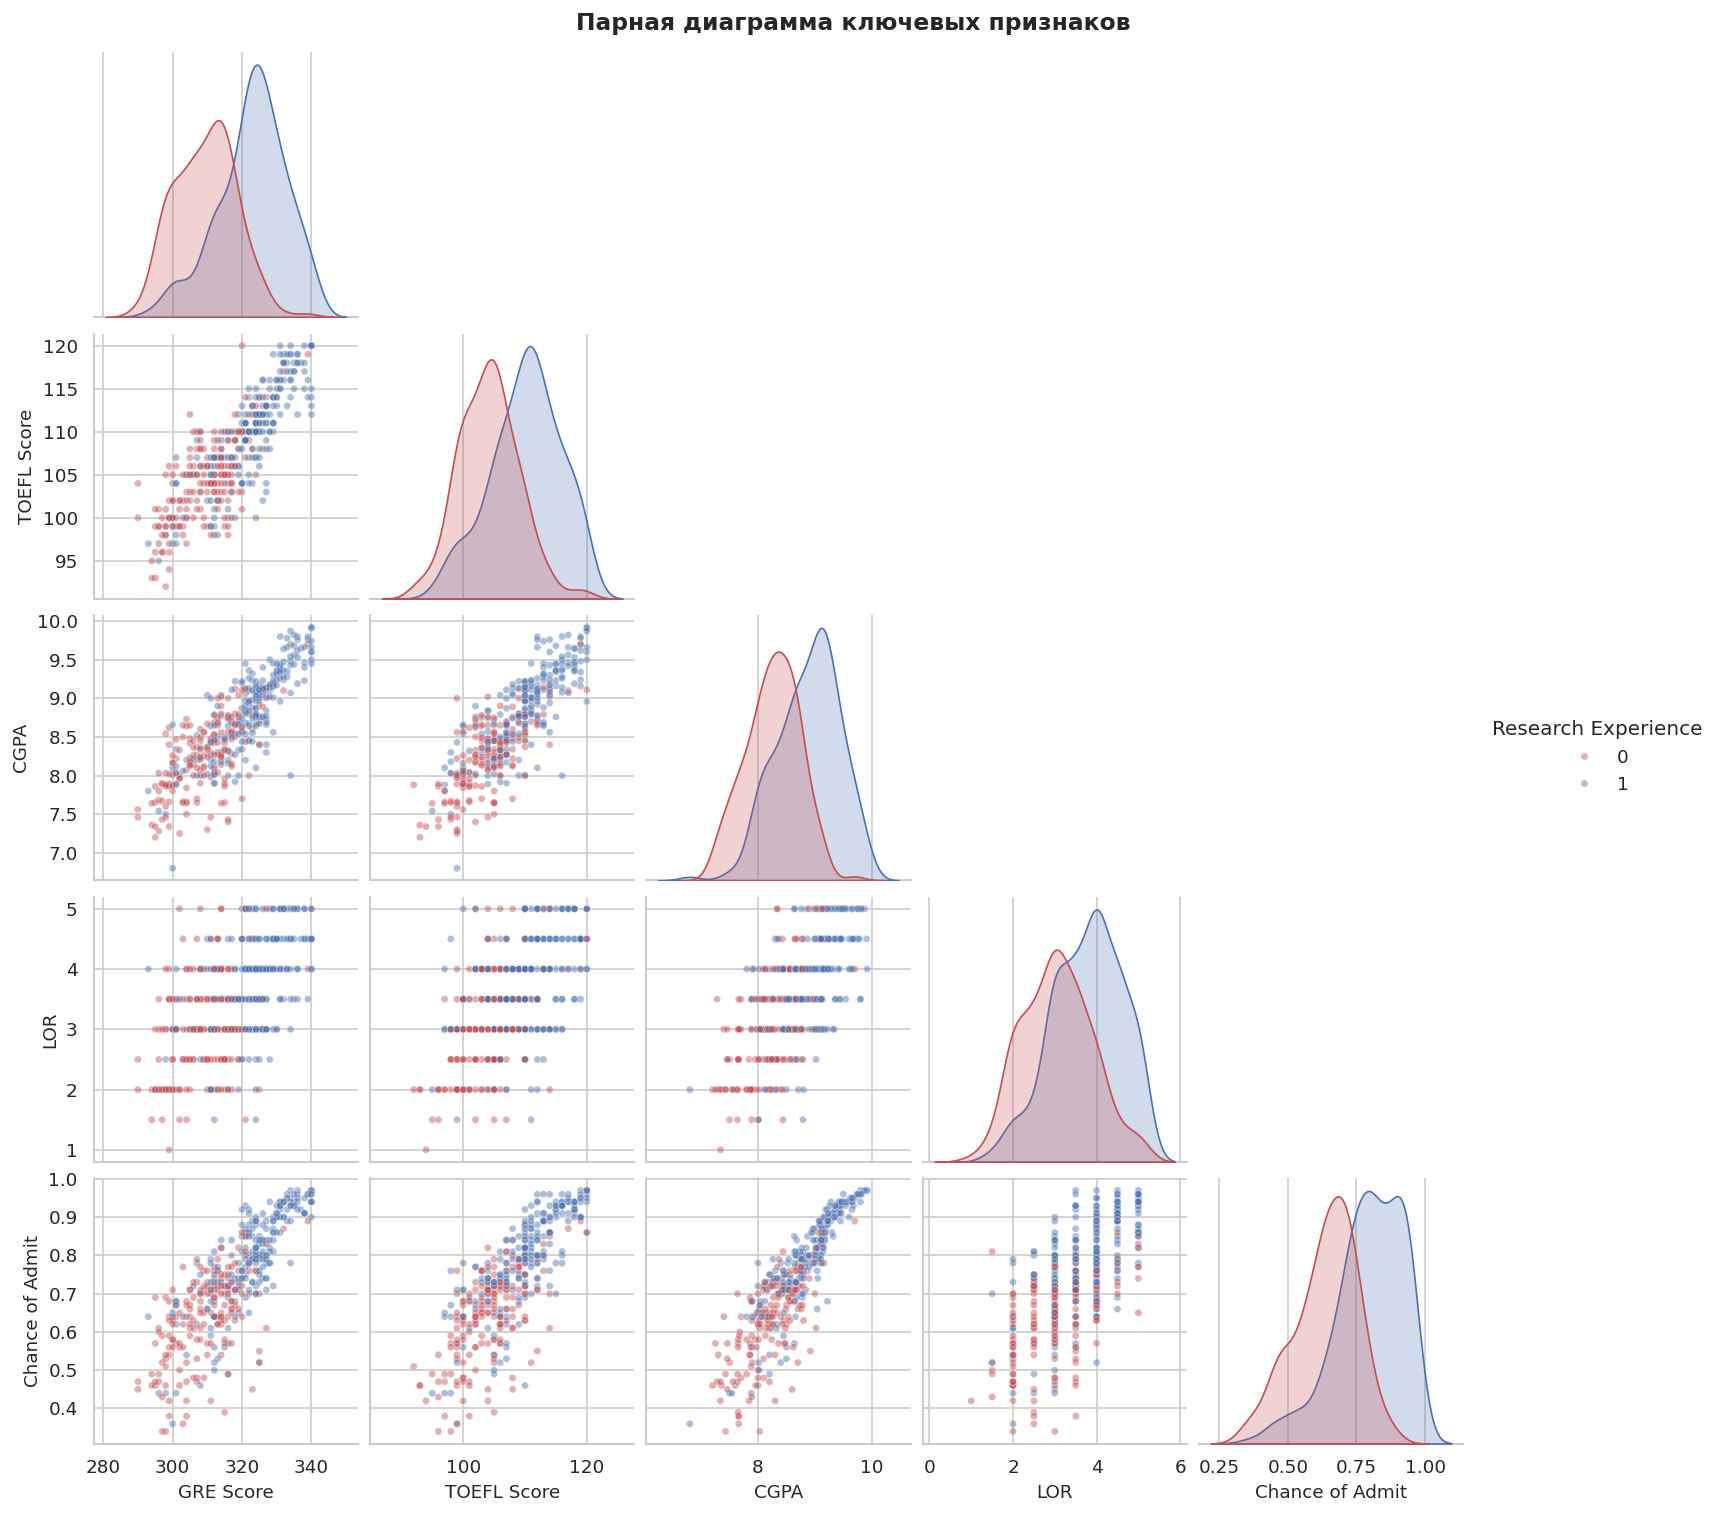

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Тепловая карта
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=axes[0],
            cbar_kws={'shrink': 0.8},
            annot_kws={'size': 10})
axes[0].set_title('Корреляционная матрица (Пирсон)', fontsize=13, pad=12)
axes[0].tick_params(axis='x', rotation=30)

# Столбчатая диаграмма корреляции с целевой переменной
target_corr = corr['Chance of Admit'].drop('Chance of Admit').sort_values(ascending=True)
colors = ['#C44E52' if v < 0 else '#4C72B0' for v in target_corr]
bars = axes[1].barh(target_corr.index, target_corr.values, color=colors, edgecolor='white', height=0.6)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Корреляция признаков с целевой переменной', fontsize=13)
axes[1].set_xlabel('Коэффициент корреляции Пирсона')
for bar, val in zip(bars, target_corr.values):
    axes[1].text(val + 0.01 if val >= 0 else val - 0.01,
                 bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}',
                 va='center', ha='left' if val >= 0 else 'right', fontsize=10)
axes[1].set_xlim(-0.1, 1.05)

plt.tight_layout()
plt.savefig('plot_correlation.png', bbox_inches='tight')
plt.show()

### 4.1 Парная диаграмма рассеяния (Pair Plot)

In [ ]:
pair_cols = ['GRE Score', 'TOEFL Score', 'CGPA', 'LOR', 'Chance of Admit']
g = sns.pairplot(df[pair_cols + ['Research']].rename(columns={'Research': 'Research Experience'}),
                 hue='Research Experience',
                 palette={0: '#C44E52', 1: '#4C72B0'},
                 plot_kws={'alpha': 0.45, 's': 18},
                 diag_kind='kde',
                 corner=True)
g.fig.suptitle('Парная диаграмма ключевых признаков', y=1.01, fontsize=14, fontweight='bold')
plt.savefig('plot_pairplot.png', bbox_inches='tight')
plt.show()

### 4.2 Выводы по корреляционному анализу

In [ ]:
target_corr_sorted = corr['Chance of Admit'].drop('Chance of Admit').sort_values(ascending=False)

print('=' * 55)
print('  ВЫВОДЫ ПО КОРРЕЛЯЦИИ С ЦЕЛЕВОЙ ПЕРЕМЕННОЙ')
print('=' * 55)
print()
for feat, val in target_corr_sorted.items():
    strength = ''
    if abs(val) >= 0.8:
        strength = '🔴 Очень сильная'
    elif abs(val) >= 0.6:
        strength = '🟠 Сильная'
    elif abs(val) >= 0.4:
        strength = '🟡 Умеренная'
    else:
        strength = '🟢 Слабая'
    print(f'  {feat:<22} r = {val:+.3f}   {strength}')

print()
print('Ключевые наблюдения:')
print('  1. CGPA показывает наибольшую корреляцию с шансом поступления (r = 0.873)')
print('  2. GRE и TOEFL также очень сильно связаны с целевой переменной')
print('  3. GRE, TOEFL и CGPA сильно коррелируют между собой — мультиколлинеарность')
print('  4. Наличие исследовательского опыта заметно повышает шансы (r = 0.553)')
print('  5. SOP и LOR имеют умеренное влияние')

  ВЫВОДЫ ПО КОРРЕЛЯЦИИ С ЦЕЛЕВОЙ ПЕРЕМЕННОЙ

  CGPA                   r = +0.873   🔴 Очень сильная
  GRE Score              r = +0.803   🔴 Очень сильная
  TOEFL Score            r = +0.792   🔴 Очень сильная
  University Rating      r = +0.711   🟠 Сильная
  SOP                    r = +0.676   🟠 Сильная
  LOR                    r = +0.670   🟠 Сильная
  Research               r = +0.553   🟡 Умеренная

Ключевые наблюдения:
  1. CGPA показывает наибольшую корреляцию с шансом поступления (r = 0.873)
  2. GRE и TOEFL также очень сильно связаны с целевой переменной
  3. GRE, TOEFL и CGPA сильно коррелируют между собой — мультиколлинеарность
  4. Наличие исследовательского опыта заметно повышает шансы (r = 0.553)
  5. SOP и LOR имеют умеренное влияние